[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wanglab-broad/FuseMap/blob/main/docs/notebooks/5_map_new_dataset_molCCF.ipynb)

In [ ]:
# Running on Google Colab? This cell installs FuseMap (~2 min). Locally it does nothing.
import sys
if "google.colab" in sys.modules:
    !pip install -q fusemap

# FuseMap Tutorial V: Mapping new datasets to molCCF

In this tutorial, we will demonstrate how to map new spatial transcriptomics data to an existing FuseMap integration. This is useful when you want to analyze new samples in the context of previously integrated datasets.

FuseMap provides functionality to project new data points into the same latent space as the reference integration, allowing you to:

1. Compare new samples to existing integrated data
2. Transfer annotations and insights from the reference to new data
3. Analyze spatial patterns across old and new datasets together

We use our pretrained base model, and then transfer the model to slideseq.

- Pre-trained base model [molCCF](https://drive.google.com/drive/folders/1auybpmekWuW_G-7YPloJr-B96qiT1nFS?usp=sharing)
- Slide-seq data: Langlieb et al., [Nature paper](https://www.nature.com/articles/s41586-023-06818-7#data-availability)

The method is similar with Tutorial IV, where you only need to change the pretrained model to molCCF.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import pickle
import numpy as np
import pandas as pd
import torch
import scanpy as sc
import matplotlib.pyplot as plt

## 1. Download the molCCF pretrained model and the query dataset

molCCF is the universal mouse brain atlas model pretrained by FuseMap. The query dataset is a
Slide-seq puck never seen during training.

In [2]:
import gdown

if not os.path.exists("./molCCF"):
    gdown.download_folder(id="1auybpmekWuW_G-7YPloJr-B96qiT1nFS", output="./molCCF", quiet=False)
os.makedirs("./tutorial5_data", exist_ok=True)
if not os.path.exists("./tutorial5_data/slideseq_Puck34.h5ad"):
    gdown.download(id="1n4eokj-r3NzoNxLGbms8LEvU3TKLjtU9", output="./tutorial5_data/slideseq_Puck34.h5ad", quiet=False)

### Coordinate columns

FuseMap looks for spatial coordinates in `obs["x"]/obs["y"]`, `obs["col"]/obs["row"]`, or
`obsm["spatial"]`. This puck stores them in custom columns (`Raw_Slideseq_X/Y`), so we assign
them once and save:

In [3]:
ad = sc.read_h5ad("./tutorial5_data/slideseq_Puck34.h5ad")
if "x" not in ad.obs.columns:
    ad.obs["x"] = ad.obs["Raw_Slideseq_X"]
    ad.obs["y"] = ad.obs["Raw_Slideseq_Y"]
    ad.write_h5ad("./tutorial5_data/slideseq_Puck34.h5ad")
print(ad)

AnnData object with n_obs × n_vars = 72542 × 20543
    obs: 'nCount_Spatial', 'nFeature_Spatial', 'PuckID', 'Raw_Slideseq_X', 'Raw_Slideseq_Y', 'Puck_Depth', 'nCount_Spatial.1', 'nFeature_Spatial.1', 'CCF_X', 'CCF_Y', 'CCF_Z', 'TopStruct', 'DeepCCF', 'CCF_acronym', 'CCF_ID', 'CCF_Name', 'CCF_LeftRight', 'IsOutsideCCF', 'Correponding_DissectateSegName', 'Correponding_DissectateSegID', 'NisslTiffX', 'NisslTiffY', 'BeadBarcode', '.id', 'orig.ident', 'x', 'y'
    obsm: 'celltype_prob'


## 2. Map to molCCF - one call

`fusemap.map_to_reference` projects every `.h5ad` in the folder into the molCCF latent space
(the reference model itself is not retrained). Results land in one subdirectory per input file.

In [4]:
import fusemap

pretrain_model_path = "./molCCF"
fusemap.map_to_reference("./tutorial5_data", "./output_tutorial5", pretrain_model_path)

output_dir = "./output_tutorial5/slideseq_Puck34.h5ad"

2026-09-05 09:19:54,227 - INFO - 

---------------------------------- Preprocess adata ----------------------------------



2026-09-05 09:20:26,777 - INFO - 

---------------------------------- Construct graph adata ----------------------------------



2026-09-05 09:20:27,072 - INFO - 

---------------------------------- Process graph adata ----------------------------------



2026-09-05 09:20:27,118 - INFO - 

number of genes in each section:[18360], Number of all genes: 18360



2026-09-05 09:20:45,540 - INFO - 

pretrain gene number:18360, new gene number:0



...

... storing 'Correponding_DissectateSegID' as categorical


... storing 'NisslTiffX' as categorical


... storing 'NisslTiffY' as categorical


... storing '.id' as categorical


... storing 'orig.ident' as categorical


In [5]:
from fusemap.utils import NNTransferTrain, NNTransfer, NNTransferPredictWithUncertainty
import torch
from sklearn import preprocessing
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.data import random_split
from torch import optim, nn
import sklearn
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import pickle

In [6]:
def transfer_annotation(molccf_path, save_dir):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    ### transfer cell type
    # Load the .pkl file
    ad_embed = sc.read_h5ad(os.path.join(save_dir, 'ad_celltype_embedding.h5ad'))
    if 'fusemap_celltype' not in ad_embed.obs.columns:
        with open(os.path.join(molccf_path, 'transfer', 'le_gt_cell_type_main_STARmap.pkl'), 'rb') as file:
            le_gt_cell_type_main_STARmap = pickle.load(file)
        
        NNmodel = NNTransfer(input_dim=64,output_dim=len(le_gt_cell_type_main_STARmap))
        NNmodel.load_state_dict(torch.load(molccf_path+"/transfer/NNtransfer_cell_type_main_STARmap.pt"))
    
        dataset = TensorDataset(torch.Tensor(ad_embed.X))
        dataloader = DataLoader(dataset, batch_size=256, shuffle=False)

        NNmodel.to(device)
        NNmodel.eval()
        all_predictions = []
        with torch.no_grad():
            for inputs in dataloader:
                inputs = inputs[0].to(device)
                outputs = NNmodel(inputs)
                _, predicted = torch.max(outputs, 1)
                all_predictions.extend(predicted.detach().cpu().numpy())
        ad_embed.obs['fusemap_celltype']=[le_gt_cell_type_main_STARmap[i] for i in all_predictions]
        ad_embed.write_h5ad(save_dir + "/ad_celltype_embedding.h5ad")

    ### transfer tissue niche
    # Load the .pkl file
    ad_embed = sc.read_h5ad(save_dir + "/ad_tissueregion_embedding.h5ad")
    if 'fusemap_tissueregion' not in ad_embed.obs.columns:
        with open(os.path.join(molccf_path, 'transfer', 'le_gt_tissue_region_main_STARmap.pkl'), 'rb') as file:
            le_gt_tissue_region_main_STARmap = pickle.load(file)
        
        NNmodel = NNTransfer(input_dim=64,output_dim=len(le_gt_tissue_region_main_STARmap))
        NNmodel.load_state_dict(torch.load(molccf_path+"/transfer/NNtransfer_tissue_region_main_STARmap.pt"))

        dataset = TensorDataset(torch.Tensor(ad_embed.X))
        dataloader = DataLoader(dataset, batch_size=256, shuffle=False)

        NNmodel.to(device)
        NNmodel.eval()
        all_predictions = []
        with torch.no_grad():
            for inputs in dataloader:
                inputs = inputs[0].to(device)
                outputs = NNmodel(inputs)
                _, predicted = torch.max(outputs, 1)
                all_predictions.extend(predicted.detach().cpu().numpy())
        ad_embed.obs['fusemap_tissueregion']=[le_gt_tissue_region_main_STARmap[i] for i in all_predictions]
        ad_embed.write_h5ad(save_dir + "/ad_tissueregion_embedding.h5ad")

In [7]:
transfer_annotation(pretrain_model_path, output_dir)

... storing 'fusemap_celltype' as categorical


... storing 'fusemap_tissueregion' as categorical


## 5. Plot transferred cell types and regions

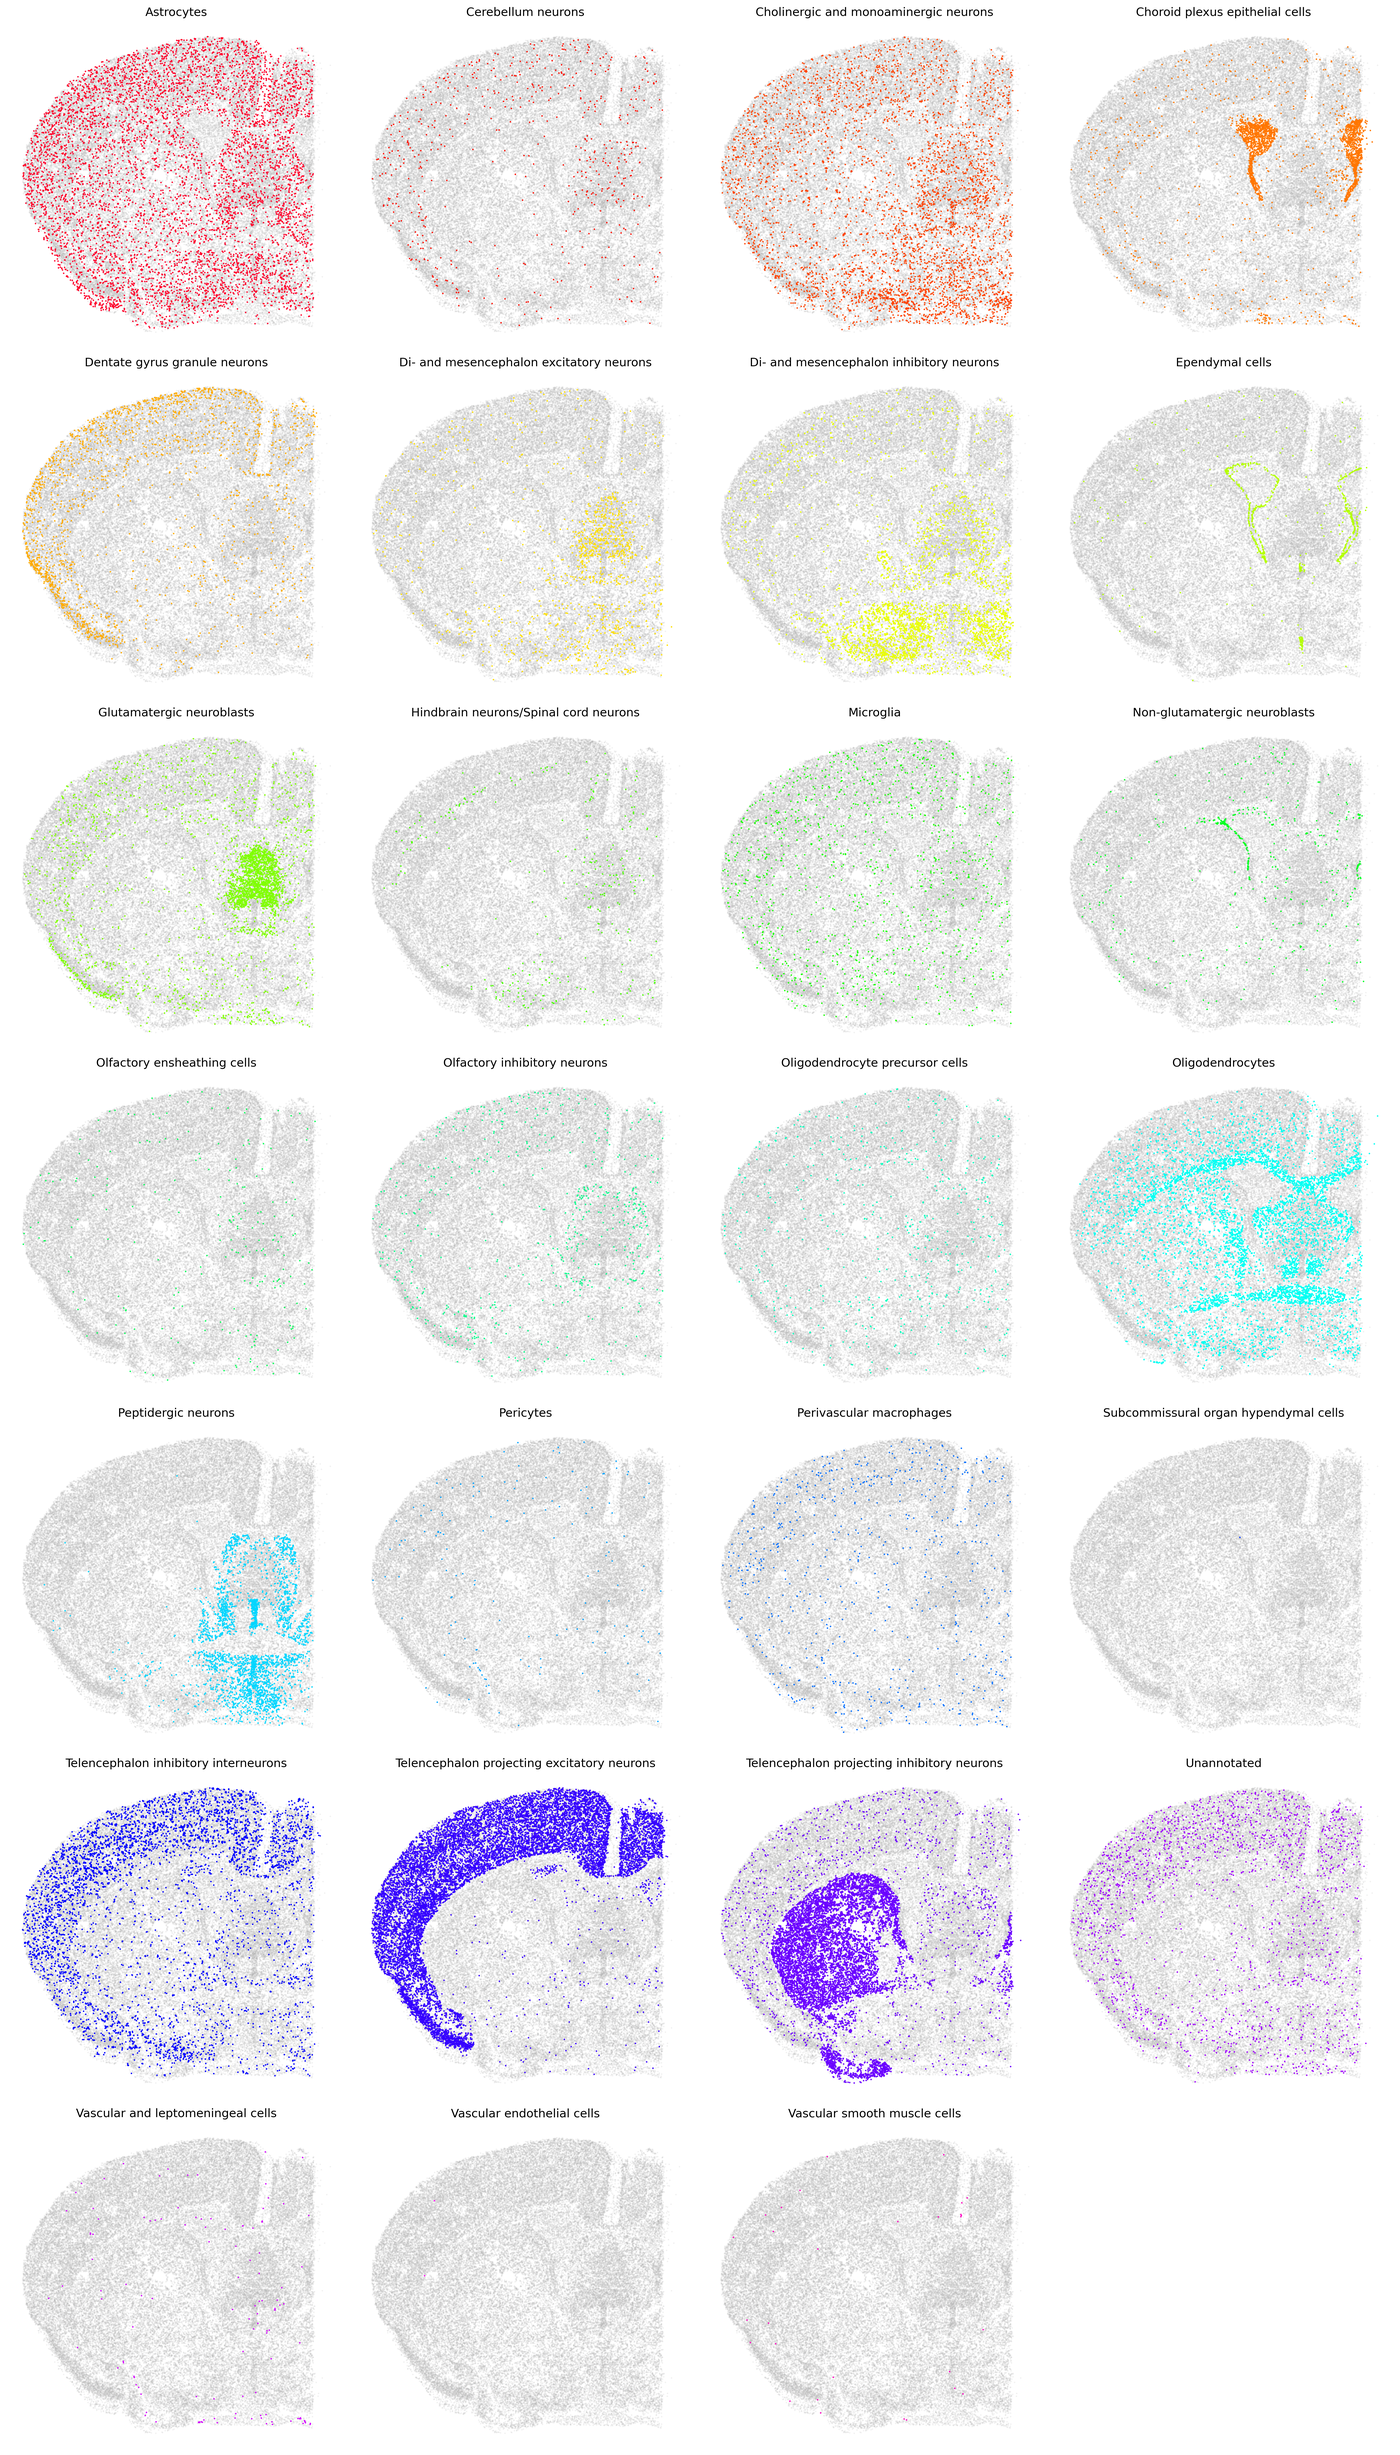

In [8]:
ad_fusemap_transfer = sc.read_h5ad(os.path.join(output_dir, 'ad_celltype_embedding.h5ad'))
cell_types = sorted(ad_fusemap_transfer.obs['fusemap_celltype'].unique())

# Generate unique colors using a continuous colormap
num_colors = len(cell_types)
cmap = plt.get_cmap('gist_rainbow', num_colors)  # 'gist_rainbow' ensures distinct colors
colors = [cmap(i / num_colors) for i in range(num_colors)]

# Create a dictionary mapping tissue types to colors
colormap = dict(zip(cell_types, colors))

plt.rcParams['figure.figsize'] = (8, 8)
plt.rcParams['figure.dpi'] = 300

# Get coordinates for sample
x = pd.to_numeric(ad_fusemap_transfer.obs['x'], errors='coerce')
y = pd.to_numeric(ad_fusemap_transfer.obs['y'], errors='coerce')

# Calculate centroid
centroid = (np.mean(x), np.mean(y))

# Center points
x_centered = x - centroid[0]
y_centered = y - centroid[1]

# Calculate scale factor to normalize points
scale = np.sqrt(np.mean(x_centered**2 + y_centered**2))

# Scale points to normalize spread
x_normalized = x_centered / scale
y_normalized = y_centered / scale

# Stack coordinates
coords = np.column_stack((x_normalized, y_normalized))

# Create a figure with subplots for each tissue type
n_tissues = len(cell_types)
n_cols = 4
n_rows = (n_tissues + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows), dpi=300)
axes = axes.flatten()

# Plot each tissue type separately
for idx, tissue in enumerate(cell_types):
    ax = axes[idx]
    mask = ad_fusemap_transfer.obs['fusemap_celltype'] == tissue
    # Plot other cells with transparency
    ax.scatter(coords[~mask, 0], coords[~mask, 1], s=0.3,
              c='gray', alpha=0.1)
    # Plot cells of current tissue type
    ax.scatter(coords[mask, 0], coords[mask, 1], s=0.3,
              c=[colormap[tissue]], label=tissue)
    ax.set_title(tissue)
    ax.axis('off')

# Remove any empty subplots
for idx in range(n_tissues, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()


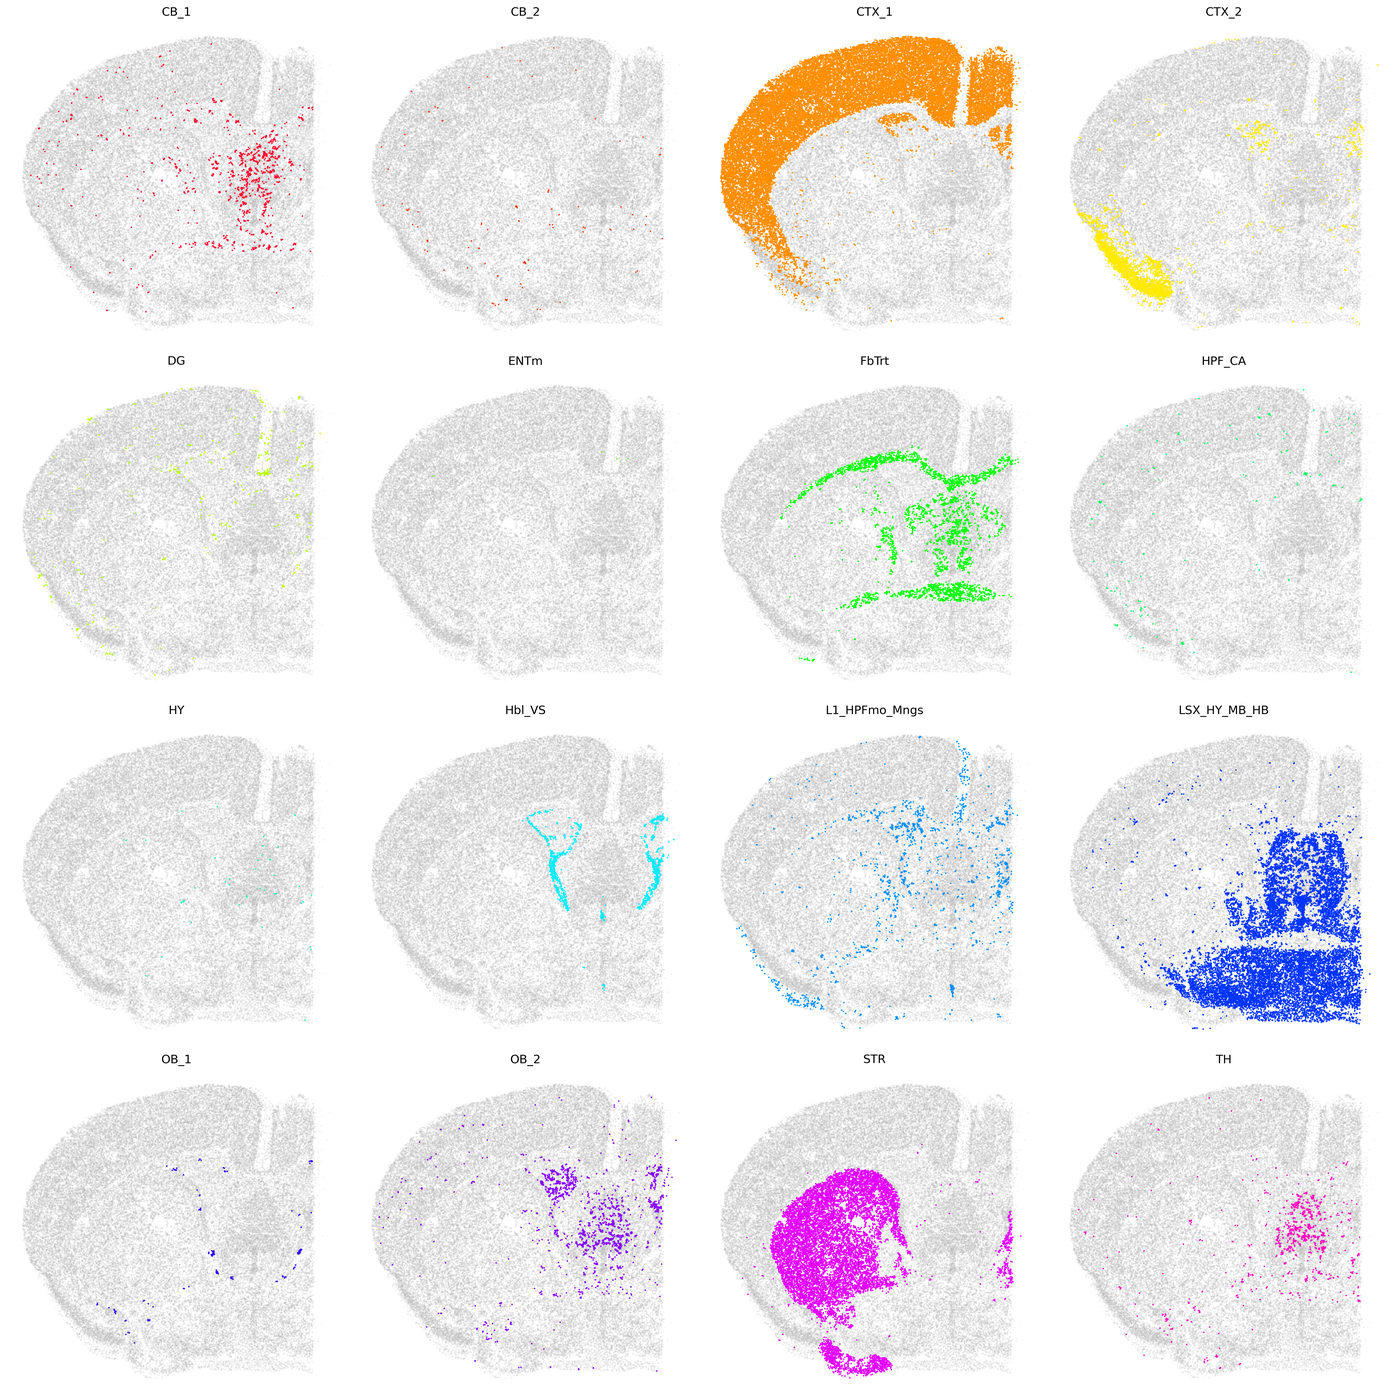

In [9]:
ad_fusemap_transfer = sc.read_h5ad(os.path.join(output_dir, 'ad_tissueregion_embedding.h5ad'))
tissue_regions = sorted(ad_fusemap_transfer.obs['fusemap_tissueregion'].unique())

# Generate unique colors using a continuous colormap
num_colors = len(tissue_regions)
cmap = plt.get_cmap('gist_rainbow', num_colors)  # 'gist_rainbow' ensures distinct colors
colors = [cmap(i / num_colors) for i in range(num_colors)]

# Create a dictionary mapping tissue types to colors
colormap = dict(zip(tissue_regions, colors))

plt.rcParams['figure.figsize'] = (8, 8)
plt.rcParams['figure.dpi'] = 300

# Get coordinates for sample
x = pd.to_numeric(ad_fusemap_transfer.obs['x'], errors='coerce')
y = pd.to_numeric(ad_fusemap_transfer.obs['y'], errors='coerce')

# Calculate centroid
centroid = (np.mean(x), np.mean(y))

# Center points
x_centered = x - centroid[0]
y_centered = y - centroid[1]

# Calculate scale factor to normalize points
scale = np.sqrt(np.mean(x_centered**2 + y_centered**2))

# Scale points to normalize spread
x_normalized = x_centered / scale
y_normalized = y_centered / scale

# Stack coordinates
coords = np.column_stack((x_normalized, y_normalized))

# Create a figure with subplots for each tissue region
n_regions = len(tissue_regions)
n_cols = 4
n_rows = (n_regions + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows), dpi=300)
axes = axes.flatten()

# Plot each tissue region separately
for idx, region in enumerate(tissue_regions):
    ax = axes[idx]
    mask = ad_fusemap_transfer.obs['fusemap_tissueregion'] == region
    # Plot other cells with transparency
    ax.scatter(coords[~mask, 0], coords[~mask, 1], s=0.3,
              c='gray', alpha=0.1)
    # Plot cells of current tissue region
    ax.scatter(coords[mask, 0], coords[mask, 1], s=0.3,
              c=[colormap[region]], label=region)
    ax.set_title(region)
    ax.axis('off')

# Remove any empty subplots
for idx in range(n_regions, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()
